<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: DataLoader sanity check

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

images, masks = next(iter(train_loader))

print("\nImage shape:", images.shape)
print("Mask shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Mask min:", masks.min().item())
print("Mask max:", masks.max().item())

NameError: name 'train_loader' is not defined

In [2]:
# Check what DataLoader-related variables currently exist

print("train_loader exists:", "train_loader" in globals())
print("val_loader exists:", "val_loader" in globals())
print("test_loader exists:", "test_loader" in globals())

print("\nVariables containing 'loader':")
print([x for x in globals().keys() if "loader" in x.lower()])

train_loader exists: False
val_loader exists: False
test_loader exists: False

Variables containing 'loader':
['__loader__']


In [3]:
import torch
import os

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
print("Current working directory:")
print(os.getcwd())

print("\nTop-level files/folders:")
print(os.listdir("/content")[:30])


Current working directory:
/content

Top-level files/folders:
['.config', 'sample_data']


In [5]:
import os

for path in [
    "/content",
    "/content/dataset",
    "/content/BUSI",
    "/content/data",
    "/content/drive/MyDrive"
]:
    print("\n", path)
    print(os.path.exists(path))


 /content
True

 /content/dataset
False

 /content/BUSI
False

 /content/data
False

 /content/drive/MyDrive
False


In [6]:
import os

print("Files/folders in /content:")
for item in os.listdir("/content"):
    print(item)

Files/folders in /content:
.config
sample_data


In [7]:
# Check whether Kaggle is configured

print("Kaggle folder exists:", os.path.exists("/root/.kaggle"))

if os.path.exists("/root/.kaggle"):
    print(os.listdir("/root/.kaggle"))

Kaggle folder exists: False


In [8]:
import os

print("Contents of /content:")
print(os.listdir("/content"))

print("\nContents of /mnt/data:")
print(os.listdir("/mnt/data") if os.path.exists("/mnt/data") else "No /mnt/data")

print("\nGoogle Drive mounted:")
print(os.path.exists("/content/drive"))

Contents of /content:
['.config', 'sample_data']

Contents of /mnt/data:
No /mnt/data

Google Drive mounted:
False


In [9]:
!pip install -q kagglehub

In [10]:
import kagglehub

path = kagglehub.dataset_download(
    "aryashah2k/breast-ultrasound-images-dataset"
)

print("Dataset downloaded to:")
print(path)

100%|██████████| 195M/195M [00:01<00:00, 125MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1


In [11]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1"

print("Dataset path exists:", os.path.exists(dataset_path))

print("\nContents:")
for item in os.listdir(dataset_path):
    print(" -", item)

Dataset path exists: True

Contents:
 - Dataset_BUSI_with_GT


In [12]:
# Show the folder structure up to 3 levels deep

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        if level < 2:
            for file in files[:10]:
                print(f"{indent}    {file}")

        if level == 2 and files:
            print(f"{indent}    ... {len(files)} files")

1/
    Dataset_BUSI_with_GT/
        malignant/
            ... 421 files
        normal/
            ... 266 files
        benign/
            ... 891 files


In [13]:
import os

# Search the downloaded dataset for CSV / TXT / JSON split files

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".csv", ".txt", ".json")):
            print(os.path.join(root, file))

In [14]:
!find /content -type f \( -name "*.csv" -o -name "*.json" -o -name "*.txt" \) 2>/dev/null | head -100

/content/.config/.last_update_check.json
/content/sample_data/anscombe.json
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv


In [15]:
import os

busi_path = os.path.join(
    dataset_path,
    "Dataset_BUSI_with_GT"
)

print("BUSI path:", busi_path)
print("\nClasses:", os.listdir(busi_path))

for class_name in ["benign", "malignant", "normal"]:
    class_path = os.path.join(busi_path, class_name)

    files = sorted(os.listdir(class_path))

    print(f"\n===== {class_name.upper()} =====")
    print("Total files:", len(files))

    print("\nFirst 20 files:")
    for f in files[:20]:
        print(f)

BUSI path: /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT

Classes: ['malignant', 'normal', 'benign']

===== BENIGN =====
Total files: 891

First 20 files:
benign (1).png
benign (1)_mask.png
benign (10).png
benign (10)_mask.png
benign (100).png
benign (100)_mask.png
benign (100)_mask_1.png
benign (101).png
benign (101)_mask.png
benign (102).png
benign (102)_mask.png
benign (103).png
benign (103)_mask.png
benign (104).png
benign (104)_mask.png
benign (105).png
benign (105)_mask.png
benign (106).png
benign (106)_mask.png
benign (107).png

===== MALIGNANT =====
Total files: 421

First 20 files:
malignant (1).png
malignant (1)_mask.png
malignant (10).png
malignant (10)_mask.png
malignant (100).png
malignant (100)_mask.png
malignant (101).png
malignant (101)_mask.png
malignant (102).png
malignant (102)_mask.png
malignant (103).png
malignant (103)_mask.png
malignant (104).png
malignant (104)_mask.png
malignant (105).png
malignant (

In [16]:
import os
import re
import pandas as pd
from PIL import Image
import numpy as np

# --------------------------------------------------
# Build image-mask pairs
# --------------------------------------------------

classes = ["benign", "malignant", "normal"]

samples = []

for class_name in classes:

    class_path = os.path.join(busi_path, class_name)

    files = os.listdir(class_path)

    # Only original images, NOT masks
    image_files = [
        f for f in files
        if f.lower().endswith(".png")
        and "_mask" not in f.lower()
    ]

    for image_file in image_files:

        # Example:
        # benign (100).png
        # -> benign (100)

        base_name = os.path.splitext(image_file)[0]

        # Find all masks belonging to this image
        mask_files = [
            f for f in files
            if f.startswith(base_name + "_mask")
            and f.lower().endswith(".png")
        ]

        samples.append({
            "class": class_name,
            "image": os.path.join(class_path, image_file),
            "image_name": image_file,
            "mask_files": [
                os.path.join(class_path, f)
                for f in sorted(mask_files)
            ]
        })

df = pd.DataFrame(samples)

print("Total image samples:", len(df))
print("\nSamples per class:")
print(df["class"].value_counts())

print("\nImages without masks:")
print((df["mask_files"].apply(len) == 0).sum())

print("\nImages with multiple masks:")
print((df["mask_files"].apply(len) > 1).sum())

Total image samples: 780

Samples per class:
class
benign       437
malignant    210
normal       133
Name: count, dtype: int64

Images without masks:
0

Images with multiple masks:
17


In [17]:
pd.set_option("display.max_colwidth", 100)

display(df.head(15))

print("\nMask count distribution:")
print(df["mask_files"].apply(len).value_counts().sort_index())

,class,image,image_name,mask_files
0,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (420).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
1,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (47).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
2,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (178).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
3,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (112).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
4,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (44).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
5,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (117).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
6,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (199).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
7,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (82).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
8,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (282).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...
9,benign,/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_B...,benign (289).png,[/root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_...



Mask count distribution:
mask_files
1    763
2     16
3      1
Name: count, dtype: int64


In [18]:
import hashlib
from collections import defaultdict

def md5_file(filepath, chunk_size=1024 * 1024):
    """
    Calculate MD5 hash of a file.
    """
    md5 = hashlib.md5()

    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            md5.update(chunk)

    return md5.hexdigest()


# --------------------------------------------------
# Calculate MD5 hashes for all images
# --------------------------------------------------

image_hashes = defaultdict(list)

for idx, row in df.iterrows():

    image_path = row["image"]

    file_hash = md5_file(image_path)

    image_hashes[file_hash].append(idx)


# Find duplicate groups
duplicate_groups = {
    h: indices
    for h, indices in image_hashes.items()
    if len(indices) > 1
}


print("Total image samples:", len(df))
print("Unique image hashes:", len(image_hashes))
print("Duplicate groups:", len(duplicate_groups))

extra_duplicates = sum(
    len(indices) - 1
    for indices in duplicate_groups.values()
)

print("Extra duplicate files:", extra_duplicates)

Total image samples: 780
Unique image hashes: 779
Duplicate groups: 1
Extra duplicate files: 1


In [19]:
for h, indices in duplicate_groups.items():

    print("\nDuplicate group:")

    for idx in indices:
        print(
            "Index:", idx,
            "| Class:", df.loc[idx, "class"],
            "| Image:", df.loc[idx, "image_name"]
        )


Duplicate group:
Index: 264 | Class: benign | Image: benign (433).png
Index: 604 | Class: malignant | Image: malignant (145).png


In [20]:
duplicate_indices = [264, 604]

for idx in duplicate_indices:

    row = df.loc[idx]

    print("\n" + "=" * 60)
    print("Index:", idx)
    print("Class:", row["class"])
    print("Image:", row["image_name"])
    print("Image path:", row["image"])

    print("\nMasks:")

    for mask_path in row["mask_files"]:
        print("  ", os.path.basename(mask_path))

    # Image information
    img = Image.open(row["image"])

    print("\nImage:")
    print("  Size:", img.size)
    print("  Mode:", img.mode)

    # Mask information
    for mask_path in row["mask_files"]:

        mask = Image.open(mask_path)

        mask_array = np.array(mask)

        print("\nMask:", os.path.basename(mask_path))
        print("  Size:", mask.size)
        print("  Unique values:", np.unique(mask_array))
        print("  Foreground pixels:", np.sum(mask_array > 0))


Index: 264
Class: benign
Image: benign (433).png
Image path: /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/benign/benign (433).png

Masks:
   benign (433)_mask.png

Image:
  Size: (550, 462)
  Mode: RGB

Mask: benign (433)_mask.png
  Size: (550, 462)
  Unique values: [False  True]
  Foreground pixels: 3186

Index: 604
Class: malignant
Image: malignant (145).png
Image path: /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT/malignant/malignant (145).png

Masks:
   malignant (145)_mask.png

Image:
  Size: (550, 462)
  Mode: RGB

Mask: malignant (145)_mask.png
  Size: (550, 462)
  Unique values: [False  True]
  Foreground pixels: 4112


In [21]:
!pip install -q imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.4 MB/s eta 0:00:00


In [22]:
import imagehash
from PIL import Image
from itertools import combinations

# Calculate perceptual hashes
phashes = {}

for idx, row in df.iterrows():
    img = Image.open(row["image"]).convert("RGB")
    phashes[idx] = imagehash.phash(img)

print("Perceptual hashes calculated:", len(phashes))

Perceptual hashes calculated: 780


In [23]:
# Find near-duplicate pairs
# Lower Hamming distance = more similar

near_duplicates = []

indices = list(phashes.keys())

for i in range(len(indices)):
    for j in range(i + 1, len(indices)):

        idx1 = indices[i]
        idx2 = indices[j]

        distance = phashes[idx1] - phashes[idx2]

        if distance <= 5:
            near_duplicates.append(
                (idx1, idx2, distance)
            )

print("Near-duplicate pairs found:", len(near_duplicates))

for idx1, idx2, distance in near_duplicates[:50]:

    print(
        f"Distance: {distance} | "
        f"{df.loc[idx1, 'class']} - {df.loc[idx1, 'image_name']} | "
        f"{df.loc[idx2, 'class']} - {df.loc[idx2, 'image_name']}"
    )

Near-duplicate pairs found: 186
Distance: 2 | benign - benign (44).png | benign - benign (129).png
Distance: 4 | benign - benign (199).png | benign - benign (248).png
Distance: 2 | benign - benign (282).png | benign - benign (204).png
Distance: 2 | benign - benign (282).png | benign - benign (249).png
Distance: 0 | benign - benign (289).png | benign - benign (273).png
Distance: 2 | benign - benign (289).png | benign - benign (203).png
Distance: 2 | benign - benign (13).png | benign - benign (330).png
Distance: 2 | benign - benign (241).png | benign - benign (266).png
Distance: 2 | benign - benign (241).png | benign - benign (279).png
Distance: 2 | benign - benign (295).png | benign - benign (231).png
Distance: 2 | benign - benign (238).png | benign - benign (300).png
Distance: 2 | benign - benign (65).png | benign - benign (99).png
Distance: 0 | benign - benign (65).png | benign - benign (139).png
Distance: 0 | benign - benign (65).png | benign - benign (157).png
Distance: 0 | benign -

In [24]:
# Check perceptual-hash distance 0 pairs

zero_distance_pairs = [
    (idx1, idx2, distance)
    for idx1, idx2, distance in near_duplicates
    if distance == 0
]

print("Distance-0 pairs:", len(zero_distance_pairs))

for idx1, idx2, distance in zero_distance_pairs:

    print(
        f"{df.loc[idx1, 'class']} - {df.loc[idx1, 'image_name']}"
        f"  <-->  "
        f"{df.loc[idx2, 'class']} - {df.loc[idx2, 'image_name']}"
    )

Distance-0 pairs: 44
benign - benign (289).png  <-->  benign - benign (273).png
benign - benign (65).png  <-->  benign - benign (139).png
benign - benign (65).png  <-->  benign - benign (157).png
benign - benign (399).png  <-->  malignant - malignant (93).png
benign - benign (234).png  <-->  benign - benign (261).png
benign - benign (312).png  <-->  benign - benign (421).png
benign - benign (37).png  <-->  benign - benign (127).png
benign - benign (422).png  <-->  benign - benign (309).png
benign - benign (35).png  <-->  benign - benign (177).png
benign - benign (18).png  <-->  benign - benign (152).png
benign - benign (164).png  <-->  benign - benign (85).png
benign - benign (299).png  <-->  benign - benign (233).png
benign - benign (225).png  <-->  benign - benign (292).png
benign - benign (258).png  <-->  benign - benign (239).png
benign - benign (263).png  <-->  benign - benign (226).png
benign - benign (222).png  <-->  benign - benign (267).png
benign - benign (306).png  <-->  ben

In [25]:
print("=" * 80)

for idx1, idx2, distance in zero_distance_pairs:

    path1 = df.loc[idx1, "image"]
    path2 = df.loc[idx2, "image"]

    hash1 = md5_file(path1)
    hash2 = md5_file(path2)

    print("\nImage 1:", df.loc[idx1, "image_name"])
    print("Class 1:", df.loc[idx1, "class"])

    print("Image 2:", df.loc[idx2, "image_name"])
    print("Class 2:", df.loc[idx2, "class"])

    print("MD5 identical:", hash1 == hash2)


Image 1: benign (289).png
Class 1: benign
Image 2: benign (273).png
Class 2: benign
MD5 identical: False

Image 1: benign (65).png
Class 1: benign
Image 2: benign (139).png
Class 2: benign
MD5 identical: False

Image 1: benign (65).png
Class 1: benign
Image 2: benign (157).png
Class 2: benign
MD5 identical: False

Image 1: benign (399).png
Class 1: benign
Image 2: malignant (93).png
Class 2: malignant
MD5 identical: False

Image 1: benign (234).png
Class 1: benign
Image 2: benign (261).png
Class 2: benign
MD5 identical: False

Image 1: benign (312).png
Class 1: benign
Image 2: benign (421).png
Class 2: benign
MD5 identical: False

Image 1: benign (37).png
Class 1: benign
Image 2: benign (127).png
Class 2: benign
MD5 identical: False

Image 1: benign (422).png
Class 1: benign
Image 2: benign (309).png
Class 2: benign
MD5 identical: False

Image 1: benign (35).png
Class 1: benign
Image 2: benign (177).png
Class 2: benign
MD5 identical: False

Image 1: benign (18).png
Class 1: benign
Ima

In [26]:
# --------------------------------------------------
# STEP 9: Remove the confirmed exact duplicate pair
# --------------------------------------------------

df_clean = df.copy()

# Confirmed exact duplicate/conflicting-label pair
duplicate_indices = [264, 604]

# Remove both copies because they have conflicting class labels
df_clean = df_clean.drop(index=duplicate_indices).reset_index(drop=True)

print("Original samples:", len(df))
print("Clean samples:", len(df_clean))

print("\nClass distribution:")
print(df_clean["class"].value_counts())

print("\nExpected:")
print("780 original samples")
print("778 clean samples")

Original samples: 780
Clean samples: 778

Class distribution:
class
benign       436
malignant    209
normal       133
Name: count, dtype: int64

Expected:
780 original samples
778 clean samples


In [27]:
# --------------------------------------------------
# STEP 10: Create segmentation dataframe
# --------------------------------------------------

df_seg = df_clean[
    df_clean["class"].isin(["benign", "malignant"])
].copy()

df_seg = df_seg.reset_index(drop=True)

print("Total segmentation samples:", len(df_seg))

print("\nClass distribution:")
print(df_seg["class"].value_counts())

Total segmentation samples: 645

Class distribution:
class
benign       436
malignant    209
Name: count, dtype: int64


In [28]:
# --------------------------------------------------
# STEP 11: Check mask availability
# --------------------------------------------------

mask_counts = df_seg["mask_files"].apply(len)

print("Images with 0 masks:", (mask_counts == 0).sum())
print("Images with 1 mask :", (mask_counts == 1).sum())
print("Images with 2 masks:", (mask_counts == 2).sum())
print("Images with 3 masks:", (mask_counts == 3).sum())

Images with 0 masks: 0
Images with 1 mask : 628
Images with 2 masks: 16
Images with 3 masks: 1


In [29]:
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# STEP 12A: Reproducible stratified split
# --------------------------------------------------

RANDOM_SEED = 42

# First: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df_seg,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_seg["class"]
)

# Second: split temporary into 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["class"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

print("\nTrain class distribution:")
print(train_df["class"].value_counts())

print("\nValidation class distribution:")
print(val_df["class"].value_counts())

print("\nTest class distribution:")
print(test_df["class"].value_counts())

Train: 451
Validation: 97
Test: 97
Total: 645

Train class distribution:
class
benign       305
malignant    146
Name: count, dtype: int64

Validation class distribution:
class
benign       65
malignant    32
Name: count, dtype: int64

Test class distribution:
class
benign       66
malignant    31
Name: count, dtype: int64


In [30]:
# --------------------------------------------------
# Check for image overlap
# --------------------------------------------------

train_images = set(train_df["image"])
val_images = set(val_df["image"])
test_images = set(test_df["image"])

print("Train ∩ Validation:", len(train_images & val_images))
print("Train ∩ Test:", len(train_images & test_images))
print("Validation ∩ Test:", len(val_images & test_images))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [31]:
# --------------------------------------------------
# Save frozen splits
# --------------------------------------------------

split_dir = "/content/frozen_splits"

os.makedirs(split_dir, exist_ok=True)

train_df.to_csv(
    f"{split_dir}/train_split.csv",
    index=False
)

val_df.to_csv(
    f"{split_dir}/val_split.csv",
    index=False
)

test_df.to_csv(
    f"{split_dir}/test_split.csv",
    index=False
)

print("Saved:")
print(f"{split_dir}/train_split.csv")
print(f"{split_dir}/val_split.csv")
print(f"{split_dir}/test_split.csv")

Saved:
/content/frozen_splits/train_split.csv
/content/frozen_splits/val_split.csv
/content/frozen_splits/test_split.csv


In [32]:
print(os.listdir(split_dir))

['train_split.csv', 'test_split.csv', 'val_split.csv']


In [33]:
from google.colab import files

files.download("/content/frozen_splits/train_split.csv")
files.download("/content/frozen_splits/val_split.csv")
files.download("/content/frozen_splits/test_split.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# --------------------------------------------------
# STEP 13: Create combined masks
# --------------------------------------------------

from PIL import Image
import numpy as np

combined_mask_dir = "/content/combined_masks"
os.makedirs(combined_mask_dir, exist_ok=True)

def create_combined_mask(mask_paths, output_path):

    # Read first mask
    first_mask = np.array(
        Image.open(mask_paths[0]).convert("L")
    )

    # Start with empty mask
    combined = np.zeros_like(first_mask, dtype=np.uint8)

    # Combine all masks
    for mask_path in mask_paths:

        mask = np.array(
            Image.open(mask_path).convert("L")
        )

        # Make sure dimensions match
        if mask.shape != combined.shape:
            raise ValueError(
                f"Mask size mismatch: "
                f"{mask.shape} vs {combined.shape}"
            )

        combined[mask > 0] = 255

    # Save
    Image.fromarray(combined).save(output_path)


# Create combined mask for every segmentation sample
combined_paths = []

for idx, row in df_seg.iterrows():

    output_name = f"{idx:04d}_mask.png"
    output_path = os.path.join(
        combined_mask_dir,
        output_name
    )

    create_combined_mask(
        row["mask_files"],
        output_path
    )

    combined_paths.append(output_path)


# Add combined mask path to dataframe
df_seg["combined_mask"] = combined_paths

print("Combined masks created:", len(combined_paths))

Combined masks created: 645


In [35]:
# Find an image with multiple masks

multi_mask_sample = df_seg[
    df_seg["mask_files"].apply(len) > 1
].iloc[0]

print("Image:")
print(multi_mask_sample["image_name"])

print("\nOriginal masks:")
for mask in multi_mask_sample["mask_files"]:
    print(os.path.basename(mask))

print("\nCombined mask:")
print(multi_mask_sample["combined_mask"])

Image:
benign (181).png

Original masks:
benign (181)_mask.png
benign (181)_mask_1.png

Combined mask:
/content/combined_masks/0032_mask.png


In [36]:
# Check combined mask values

combined = np.array(
    Image.open(
        multi_mask_sample["combined_mask"]
    )
)

print("Unique values:", np.unique(combined))
print("Foreground pixels:", np.sum(combined > 0))

Unique values: [  0 255]
Foreground pixels: 26899


In [37]:
# --------------------------------------------------
# STEP 15: Add combined mask paths to train/val/test
# --------------------------------------------------

# Create a lookup from original image path → combined mask
mask_lookup = dict(
    zip(
        df_seg["image"],
        df_seg["combined_mask"]
    )
)

# Add combined mask path to each split
train_df["combined_mask"] = train_df["image"].map(mask_lookup)
val_df["combined_mask"] = val_df["image"].map(mask_lookup)
test_df["combined_mask"] = test_df["image"].map(mask_lookup)

print("Missing train masks:",
      train_df["combined_mask"].isna().sum())

print("Missing validation masks:",
      val_df["combined_mask"].isna().sum())

print("Missing test masks:",
      test_df["combined_mask"].isna().sum())

Missing train masks: 0
Missing validation masks: 0
Missing test masks: 0


In [38]:
train_df.to_csv(
    "/content/frozen_splits/train_split.csv",
    index=False
)

val_df.to_csv(
    "/content/frozen_splits/val_split.csv",
    index=False
)

test_df.to_csv(
    "/content/frozen_splits/test_split.csv",
    index=False
)

print("Final split files updated.")

Final split files updated.


In [39]:
print(train_df.columns.tolist())

['class', 'image', 'image_name', 'mask_files', 'combined_mask']


In [40]:
!pip install -q albumentations

In [41]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [42]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=15,
        p=0.5
    ),

    A.RandomScale(
        scale_limit=0.1,
        p=0.5
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

In [43]:
val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

In [44]:
class BUSIDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        # -------------------------
        # Read image
        # -------------------------

        image = cv2.imread(row["image"])

        if image is None:
            raise FileNotFoundError(
                f"Could not read image: {row['image']}"
            )

        # OpenCV loads BGR
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # -------------------------
        # Read combined mask
        # -------------------------

        mask = cv2.imread(
            row["combined_mask"],
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise FileNotFoundError(
                f"Could not read mask: "
                f"{row['combined_mask']}"
            )

        # Convert 0/255 → 0/1
        mask = (mask > 0).astype(np.float32)

        # -------------------------
        # Apply transformations
        # -------------------------

        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # -------------------------
        # Make sure mask has
        # channel dimension
        # -------------------------

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return image, mask

In [45]:
train_dataset = BUSIDataset(
    train_df,
    transform=train_transform
)

val_dataset = BUSIDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BUSIDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 451
Validation dataset: 97
Test dataset: 97


In [46]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 29
Validation batches: 7
Test batches: 7


In [47]:
images, masks = next(iter(train_loader))

print("Images:")
print(" Shape:", images.shape)
print(" Dtype:", images.dtype)
print(" Min:", images.min().item())
print(" Max:", images.max().item())

print("\nMasks:")
print(" Shape:", masks.shape)
print(" Dtype:", masks.dtype)
print(" Min:", masks.min().item())
print(" Max:", masks.max().item())
print(" Unique values:", torch.unique(masks))

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py", line 57, in fetch
    return self.collate_fn(data)
           ~~~~~~~~~~~~~~~^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/collate.py", line 401, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/collate.py", line 215, in collate
    collate(samples, collate_fn_map=collate_fn_map)
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/collate.py", line 155, in collate
    return collate_fn_map[elem_type](batch, collat

In [48]:
# --------------------------------------------------
# STEP 22: Debug DataLoader
# --------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("DataLoaders recreated with num_workers=0")

DataLoaders recreated with num_workers=0


In [49]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)

print("Masks shape:", masks.shape)
print("Masks dtype:", masks.dtype)

print("Mask unique values:", torch.unique(masks))

RuntimeError: stack expects each tensor to be equal size, but got [3, 256, 256] at entry 0 and [3, 231, 231] at entry 1

In [50]:
A.Resize(256, 256)
A.RandomScale(scale_limit=0.1)

RandomScale(p=0.5, area_for_downscale=None, interpolation=1, mask_interpolation=0, scale_limit=(-0.1, 0.1))

In [51]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=15,
        p=0.5
    ),

    A.RandomScale(
        scale_limit=0.1,
        p=0.5
    ),

    # IMPORTANT:
    # Final resize guarantees identical dimensions
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

In [52]:
val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

In [53]:
train_dataset = BUSIDataset(
    train_df,
    transform=train_transform
)

val_dataset = BUSIDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BUSIDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 451
Validation dataset: 97
Test dataset: 97


In [54]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 29
Validation batches: 7
Test batches: 7


In [55]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)

print("Masks shape:", masks.shape)
print("Masks dtype:", masks.dtype)

print("Mask unique values:", torch.unique(masks))

Images shape: torch.Size([16, 3, 256, 256])
Images dtype: torch.float32
Masks shape: torch.Size([16, 1, 256, 256])
Masks dtype: torch.float32
Mask unique values: tensor([0., 1.])


In [56]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [58]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [59]:
class AttentionGate(nn.Module):

    def __init__(
        self,
        F_g,
        F_l,
        F_int
    ):

        super().__init__()

        # Transform decoder/gating signal
        self.W_g = nn.Sequential(

            nn.Conv2d(
                F_g,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),

            nn.BatchNorm2d(F_int)
        )

        # Transform encoder skip connection
        self.W_x = nn.Sequential(

            nn.Conv2d(
                F_l,
                F_int,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),

            nn.BatchNorm2d(F_int)
        )

        # Produce attention coefficient
        self.psi = nn.Sequential(

            nn.Conv2d(
                F_int,
                1,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),

            nn.BatchNorm2d(1),

            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        # g = decoder signal
        # x = encoder skip connection

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # Make sure spatial dimensions match
        if g1.shape[2:] != x1.shape[2:]:

            g1 = F.interpolate(
                g1,
                size=x1.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        # Apply attention coefficient
        return x * psi

In [60]:
class AttentionDecoder(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionGate(
            F_g=out_channels,
            F_l=skip_channels,
            F_int=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        # Match spatial dimensions
        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        # Attention on skip connection
        skip = self.attention(
            g=x,
            x=skip
        )

        # Concatenate
        x = torch.cat(
            [skip, x],
            dim=1
        )

        return self.conv(x)

In [61]:
class AttentionUNet(nn.Module):

    def __init__(self, in_channels=3, out_channels=1):

        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = DoubleConv(
            in_channels,
            64
        )

        self.enc2 = DoubleConv(
            64,
            128
        )

        self.enc3 = DoubleConv(
            128,
            256
        )

        self.enc4 = DoubleConv(
            256,
            512
        )

        # -------------------------
        # Pooling
        # -------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.dec4 = AttentionDecoder(
            in_channels=1024,
            skip_channels=512,
            out_channels=512
        )

        self.dec3 = AttentionDecoder(
            in_channels=512,
            skip_channels=256,
            out_channels=256
        )

        self.dec2 = AttentionDecoder(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.dec1 = AttentionDecoder(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        # -------------------------
        # Final segmentation layer
        # -------------------------

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.dec4(b, e4)

        d3 = self.dec3(d4, e3)

        d2 = self.dec2(d3, e2)

        d1 = self.dec1(d2, e1)

        # Output logits
        out = self.final(d1)

        return out

In [62]:
model = AttentionUNet(
    in_channels=3,
    out_channels=1
).to(device)

print(model)

AttentionUNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, ker

In [63]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", total_params)
print("Trainable parameters:", trainable_params)


Total parameters: 31395053
Trainable parameters: 31395053


In [64]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():

    outputs = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([16, 3, 256, 256])
Mask shape  : torch.Size([16, 1, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])


In [65]:
outputs = model(images)

In [66]:
probability = torch.sigmoid(logits)

NameError: name 'logits' is not defined

In [67]:
def dice_loss(logits, targets, smooth=1e-6):

    # Convert logits → probabilities
    probs = torch.sigmoid(logits)

    # Flatten
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    # Intersection
    intersection = (probs * targets).sum(dim=1)

    # Dice coefficient
    dice = (
        (2.0 * intersection + smooth)
        /
        (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    # Dice loss
    return 1.0 - dice.mean()

In [68]:
bce_loss = nn.BCEWithLogitsLoss()

In [69]:
def combined_loss(logits, targets):

    bce = bce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return bce + dice

In [70]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = combined_loss(
    outputs,
    masks
)

print("Output shape:", outputs.shape)
print("Mask shape:", masks.shape)
print("Loss:", loss.item())

Output shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 1, 256, 256])
Loss: 1.4847114086151123


In [71]:
def dice_score(logits, targets, threshold=0.5, smooth=1e-6):

    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)

    dice = (
        (2.0 * intersection + smooth)
        /
        (
            preds.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return dice.mean().item()

In [72]:
dice = dice_score(
    outputs,
    masks
)

print("Dice score:", dice)

Dice score: 0.1056184396147728


In [73]:
def iou_score(logits, targets, threshold=0.5, smooth=1e-6):

    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)

    union = (
        preds.sum(dim=1)
        + targets.sum(dim=1)
        - intersection
    )

    iou = (
        (intersection + smooth)
        / (union + smooth)
    )

    return iou.mean().item()

In [74]:
def classification_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6
):

    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    TP = (preds * targets).sum(dim=1)

    TN = ((1 - preds) * (1 - targets)).sum(dim=1)

    FP = (preds * (1 - targets)).sum(dim=1)

    FN = ((1 - preds) * targets).sum(dim=1)

    precision = (
        (TP + smooth)
        /
        (TP + FP + smooth)
    )

    recall = (
        (TP + smooth)
        /
        (TP + FN + smooth)
    )

    specificity = (
        (TN + smooth)
        /
        (TN + FP + smooth)
    )

    return {
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
        "specificity": specificity.mean().item()
    }

In [75]:
dice = dice_score(outputs, masks)
iou = iou_score(outputs, masks)

cls_metrics = classification_metrics(
    outputs,
    masks
)

print("Dice       :", dice)
print("IoU        :", iou)
print("Precision  :", cls_metrics["precision"])
print("Recall     :", cls_metrics["recall"])
print("Specificity:", cls_metrics["specificity"])

Dice       : 0.1056184396147728
IoU        : 0.05669444054365158
Precision  : 0.08835570514202118
Recall     : 0.20594468712806702
Specificity: 0.8515483736991882


In [76]:
!pip install -q scipy

In [77]:
import numpy as np
from scipy.ndimage import (
    binary_erosion,
    distance_transform_edt
)

In [78]:
def hd95_single(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    # If both masks are empty
    if not pred.any() and not target.any():
        return 0.0

    # If one is empty and the other isn't
    if not pred.any() or not target.any():
        return np.inf

    # Extract boundaries
    pred_boundary = pred ^ binary_erosion(pred)
    target_boundary = target ^ binary_erosion(target)

    # Distance maps
    target_distance = distance_transform_edt(
        ~target_boundary
    )

    pred_distance = distance_transform_edt(
        ~pred_boundary
    )

    # Distances from predicted boundary to target boundary
    pred_to_target = target_distance[pred_boundary]

    # Distances from target boundary to predicted boundary
    target_to_pred = pred_distance[target_boundary]

    all_distances = np.concatenate([
        pred_to_target,
        target_to_pred
    ])

    return np.percentile(
        all_distances,
        95
    )

In [79]:
def hd95_score(logits, targets, threshold=0.5):

    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).detach().cpu().numpy()
    targets = targets.detach().cpu().numpy()

    hd95_values = []

    for pred, target in zip(preds, targets):

        # Remove channel dimension
        pred = pred.squeeze()
        target = target.squeeze()

        value = hd95_single(
            pred,
            target
        )

        hd95_values.append(value)

    # Ignore infinite values for batch average
    finite_values = [
        x for x in hd95_values
        if np.isfinite(x)
    ]

    if len(finite_values) == 0:
        return float("inf")

    return float(np.mean(finite_values))

In [80]:
hd95 = hd95_score(
    outputs,
    masks
)

print("HD95:", hd95)

HD95: 155.130988418056


In [81]:
def calculate_metrics(logits, targets):

    dice = dice_score(
        logits,
        targets
    )

    iou = iou_score(
        logits,
        targets
    )

    cls = classification_metrics(
        logits,
        targets
    )

    hd95 = hd95_score(
        logits,
        targets
    )

    return {
        "Dice": dice,
        "IoU": iou,
        "Precision": cls["precision"],
        "Recall": cls["recall"],
        "Specificity": cls["specificity"],
        "HD95": hd95
    }

In [82]:
metrics = calculate_metrics(
    outputs,
    masks
)

print(metrics)

{'Dice': 0.1056184396147728, 'IoU': 0.05669444054365158, 'Precision': 0.08835570514202118, 'Recall': 0.20594468712806702, 'Specificity': 0.8515483736991882, 'HD95': 155.130988418056}


In [83]:
# --------------------------------------------------
# STEP 47: Optimizer
# --------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)


In [84]:
# --------------------------------------------------
# STEP 48: Training function
# --------------------------------------------------

def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = combined_loss(
            outputs,
            masks
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss / len(loader)
    )

    return epoch_loss

In [85]:
# --------------------------------------------------
# STEP 49: Validation function
# --------------------------------------------------

def validate_one_epoch(
    model,
    loader,
    device
):

    model.eval()

    running_loss = 0.0

    dice_values = []
    iou_values = []

    precision_values = []
    recall_values = []
    specificity_values = []

    hd95_values = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Forward
            outputs = model(images)

            # Loss
            loss = combined_loss(
                outputs,
                masks
            )

            running_loss += loss.item()

            # Metrics
            metrics = calculate_metrics(
                outputs,
                masks
            )

            dice_values.append(
                metrics["Dice"]
            )

            iou_values.append(
                metrics["IoU"]
            )

            precision_values.append(
                metrics["Precision"]
            )

            recall_values.append(
                metrics["Recall"]
            )

            specificity_values.append(
                metrics["Specificity"]
            )

            if np.isfinite(metrics["HD95"]):

                hd95_values.append(
                    metrics["HD95"]
                )

    return {
        "loss":
            running_loss / len(loader),

        "Dice":
            np.mean(dice_values),

        "IoU":
            np.mean(iou_values),

        "Precision":
            np.mean(precision_values),

        "Recall":
            np.mean(recall_values),

        "Specificity":
            np.mean(specificity_values),

        "HD95":
            np.mean(hd95_values)
            if hd95_values
            else np.inf
    }

In [86]:
# --------------------------------------------------
# STEP 50: Short training sanity check
# --------------------------------------------------

EPOCHS = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_specificity": [],
    "val_hd95": []
}

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["val_dice"].append(
        val_metrics["Dice"]
    )

    history["val_iou"].append(
        val_metrics["IoU"]
    )

    history["val_precision"].append(
        val_metrics["Precision"]
    )

    history["val_recall"].append(
        val_metrics["Recall"]
    )

    history["val_specificity"].append(
        val_metrics["Specificity"]
    )

    history["val_hd95"].append(
        val_metrics["HD95"]
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Dice: {val_metrics['Dice']:.4f} | "
        f"Val IoU: {val_metrics['IoU']:.4f} | "
        f"Val HD95: {val_metrics['HD95']:.2f}"
    )

OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 55.81 MiB is free. Including non-PyTorch memory, this process has 14.51 GiB memory in use. Of the allocated memory 13.22 GiB is allocated by PyTorch, and 1.16 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [87]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"GPU memory reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

GPU memory allocated: 12.97 GB
GPU memory reserved: 14.38 GB


In [88]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 113
Val batches: 25
Test batches: 25


In [89]:
model.train()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

optimizer.zero_grad()

outputs = model(images)

loss = combined_loss(
    outputs,
    masks
)

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Outputs:", outputs.shape)
print("Loss:", loss.item())

loss.backward()

optimizer.step()

print("Backward pass successful!")

OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 53.81 MiB is free. Including non-PyTorch memory, this process has 14.51 GiB memory in use. Of the allocated memory 14.23 GiB is allocated by PyTorch, and 156.63 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [90]:
# --------------------------------------------------
# STEP 54: Completely clear GPU memory
# --------------------------------------------------

import gc
import torch

# Delete objects that may still hold GPU memory
for var in [
    "outputs",
    "loss",
    "images",
    "masks",
    "model",
    "optimizer"
]:
    if var in globals():
        del globals()[var]

# Python garbage collection
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print(
    f"GPU allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"GPU reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

GPU allocated: 1.38 GB
GPU reserved: 7.75 GB


In [91]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 10           |        cudaMalloc retries: 12        |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   1413 MiB |  14637 MiB | 130403 MiB | 128989 MiB |
|       from large pool |   1407 MiB |  14616 MiB | 130303 MiB | 128896 MiB |
|       from small pool |      6 MiB |     22 MiB |     99 MiB |     93 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   1413 MiB |  14637 MiB | 130403 MiB | 128989 MiB |
|       from large pool |   1407 MiB |  14616 MiB | 130303 MiB |

In [92]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("GPU allocated:",
      round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")

print("GPU reserved:",
      round(torch.cuda.memory_reserved() / 1024**3, 2), "GB")

GPU allocated: 1.38 GB
GPU reserved: 7.75 GB


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [2]:
import glob
import os

for name in [
    "train_split.csv",
    "val_split.csv",
    "test_split.csv"
]:
    matches = glob.glob(
        f"/content/**/{name}",
        recursive=True
    )

    print(f"\n{name}:")

    if matches:
        for path in matches:
            print("  ", path)
    else:
        print("   NOT FOUND")


train_split.csv:
   /content/frozen_splits/train_split.csv

val_split.csv:
   /content/frozen_splits/val_split.csv

test_split.csv:
   /content/frozen_splits/test_split.csv


In [3]:
BUSI_PATH = (
    "/root/.cache/kagglehub/datasets/"
    "aryashah2k/breast-ultrasound-images-dataset/"
    "versions/1/Dataset_BUSI_with_GT"
)

print("\nBUSI exists:", os.path.exists(BUSI_PATH))
print("BUSI path:", BUSI_PATH)


BUSI exists: True
BUSI path: /root/.cache/kagglehub/datasets/aryashah2k/breast-ultrasound-images-dataset/versions/1/Dataset_BUSI_with_GT


In [4]:
import glob

for name in [
    "train_split.csv",
    "val_split.csv",
    "test_split.csv"
]:
    matches = glob.glob(
        f"/content/**/{name}",
        recursive=True
    )

    print(f"\n{name}:")

    if matches:
        for path in matches:
            print("  FOUND:", path)
    else:
        print("  NOT FOUND")


train_split.csv:
  FOUND: /content/frozen_splits/train_split.csv

val_split.csv:
  FOUND: /content/frozen_splits/val_split.csv

test_split.csv:
  FOUND: /content/frozen_splits/test_split.csv


In [5]:
import pandas as pd

TRAIN_CSV = "/content/frozen_splits/train_split.csv"
VAL_CSV   = "/content/frozen_splits/val_split.csv"
TEST_CSV  = "/content/frozen_splits/test_split.csv"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nFirst 3 training rows:")
display(train_df.head(3))

Train samples: 451
Validation samples: 97
Test samples: 97

Train columns:
['class', 'image', 'image_name', 'mask_files', 'combined_mask']

First 3 training rows:


,class,image,image_name,mask_files,combined_mask
0,benign,/root/.cache/kagglehub/datasets/aryashah2k/bre...,benign (135).png,['/root/.cache/kagglehub/datasets/aryashah2k/b...,/content/combined_masks/0367_mask.png
1,benign,/root/.cache/kagglehub/datasets/aryashah2k/bre...,benign (117).png,['/root/.cache/kagglehub/datasets/aryashah2k/b...,/content/combined_masks/0005_mask.png
2,benign,/root/.cache/kagglehub/datasets/aryashah2k/bre...,benign (58).png,['/root/.cache/kagglehub/datasets/aryashah2k/b...,/content/combined_masks/0249_mask.png


In [6]:
print("TRAIN")
print(train_df.head())

print("\nVAL")
print(val_df.head())

print("\nTEST")
print(test_df.head())

TRAIN
    class                                              image  \
0  benign  /root/.cache/kagglehub/datasets/aryashah2k/bre...   
1  benign  /root/.cache/kagglehub/datasets/aryashah2k/bre...   
2  benign  /root/.cache/kagglehub/datasets/aryashah2k/bre...   
3  benign  /root/.cache/kagglehub/datasets/aryashah2k/bre...   
4  benign  /root/.cache/kagglehub/datasets/aryashah2k/bre...   

         image_name                                         mask_files  \
0  benign (135).png  ['/root/.cache/kagglehub/datasets/aryashah2k/b...   
1  benign (117).png  ['/root/.cache/kagglehub/datasets/aryashah2k/b...   
2   benign (58).png  ['/root/.cache/kagglehub/datasets/aryashah2k/b...   
3  benign (261).png  ['/root/.cache/kagglehub/datasets/aryashah2k/b...   
4  benign (138).png  ['/root/.cache/kagglehub/datasets/aryashah2k/b...   

                           combined_mask  
0  /content/combined_masks/0367_mask.png  
1  /content/combined_masks/0005_mask.png  
2  /content/combined_masks/0249_mas

In [7]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=15,
        p=0.5
    ),

    A.RandomScale(
        scale_limit=0.1,
        p=0.5
    ),

    # MUST be last spatial operation
    A.Resize(
        IMG_SIZE,
        IMG_SIZE
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(
        IMG_SIZE,
        IMG_SIZE
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

print("Transforms created.")

NameError: name 'A' is not defined

In [8]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass distribution:")
print("\nTRAIN")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTEST")
print(test_df["class"].value_counts())

Train: 451
Validation: 97
Test: 97

Class distribution:

TRAIN
class
benign       305
malignant    146
Name: count, dtype: int64

VALIDATION
class
benign       65
malignant    32
Name: count, dtype: int64

TEST
class
benign       66
malignant    31
Name: count, dtype: int64


In [9]:
import os

print(
    "Train combined masks:",
    train_df["combined_mask"].apply(os.path.exists).sum(),
    "/",
    len(train_df)
)

print(
    "Validation combined masks:",
    val_df["combined_mask"].apply(os.path.exists).sum(),
    "/",
    len(val_df)
)

print(
    "Test combined masks:",
    test_df["combined_mask"].apply(os.path.exists).sum(),
    "/",
    len(test_df)
)

Train combined masks: 451 / 451
Validation combined masks: 97 / 97
Test combined masks: 97 / 97


In [10]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=15,
        p=0.5
    ),

    A.RandomScale(
        scale_limit=0.1,
        p=0.5
    ),

    # Always finish with fixed size
    A.Resize(
        IMG_SIZE,
        IMG_SIZE
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


val_test_transform = A.Compose([
    A.Resize(
        IMG_SIZE,
        IMG_SIZE
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

print("Transforms ready.")

NameError: name 'A' is not defined

In [11]:
import os
import gc
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("All imports successful.")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

All imports successful.
PyTorch: 2.11.0+cu128
CUDA: True


In [12]:
TRAIN_CSV = "/content/frozen_splits/train_split.csv"
VAL_CSV   = "/content/frozen_splits/val_split.csv"
TEST_CSV  = "/content/frozen_splits/test_split.csv"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 451
Validation: 97
Test: 97


In [13]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

print("Transforms ready.")

Transforms ready.


In [14]:
class BUSISegmentationDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # -----------------------------
        # Load ultrasound image
        # -----------------------------
        image = np.array(
            Image.open(row["image"]).convert("RGB")
        )

        # -----------------------------
        # Load combined lesion mask
        # -----------------------------
        mask = np.array(
            Image.open(row["combined_mask"]).convert("L")
        )

        # Convert mask:
        # 0   -> background
        # 255 -> lesion
        # into:
        # 0   -> background
        # 1   -> lesion
        mask = (mask > 0).astype(np.uint8)

        # -----------------------------
        # Apply transformations
        # -----------------------------
        if self.transform is not None:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # -----------------------------
        # Ensure mask is [1,H,W]
        # -----------------------------
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return image, mask

In [15]:
train_dataset = BUSISegmentationDataset(
    train_df,
    transform=train_transform
)

val_dataset = BUSISegmentationDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BUSISegmentationDataset(
    test_df,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 451
Validation dataset: 97
Test dataset: 97


In [16]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 113
Validation batches: 25
Test batches: 25


In [17]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)

print("Masks shape:", masks.shape)
print("Masks dtype:", masks.dtype)

print("Mask unique values:", torch.unique(masks))

Images shape: torch.Size([4, 3, 256, 256])
Images dtype: torch.float32
Masks shape: torch.Size([4, 1, 256, 256])
Masks dtype: torch.float32
Mask unique values: tensor([0., 1.])


In [18]:
# ============================================================
# STEP 11: Attention U-Net building blocks
# ============================================================

class DoubleConv(nn.Module):
    """
    Two consecutive 3x3 convolutions,
    each followed by BatchNorm and ReLU.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Attention gate for a U-Net skip connection.

    g    = decoder/gating feature
    skip = encoder feature
    """

    def __init__(
        self,
        gate_channels,
        skip_channels,
        inter_channels
    ):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(
                gate_channels,
                inter_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),
            nn.BatchNorm2d(inter_channels)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(
                skip_channels,
                inter_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),
            nn.BatchNorm2d(inter_channels)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(
                inter_channels,
                1,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        # Transform gating signal
        g1 = self.W_g(g)

        # Transform skip feature
        x1 = self.W_x(x)

        # They must have the same spatial size
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(
                g1,
                size=x1.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        # Attention coefficients
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        # Apply attention to skip connection
        return x * psi


class AttentionDecoder(nn.Module):
    """
    Upsampling + attention-gated skip connection + DoubleConv.
    """

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.attention = AttentionGate(
            gate_channels=out_channels,
            skip_channels=skip_channels,
            inter_channels=out_channels // 2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        # Upsample decoder feature
        x = self.up(x)

        # Make spatial dimensions match
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        # Attention-gate the skip connection
        skip = self.attention(x, skip)

        # Concatenate
        x = torch.cat(
            [skip, x],
            dim=1
        )

        # Convolution
        x = self.conv(x)

        return x

In [19]:
# ============================================================
# STEP 12: Attention U-Net
# ============================================================

class AttentionUNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.enc4 = DoubleConv(
            128,
            256
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = DoubleConv(
            256,
            512
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.dec4 = AttentionDecoder(
            in_channels=512,
            skip_channels=256,
            out_channels=256
        )

        self.dec3 = AttentionDecoder(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.dec2 = AttentionDecoder(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        self.dec1 = AttentionDecoder(
            in_channels=64,
            skip_channels=32,
            out_channels=32
        )

        # -------------------------
        # Final 1x1 convolution
        # -------------------------

        self.final = nn.Conv2d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # Bottleneck
        b = self.bottleneck(
            self.pool(e4)
        )

        # Decoder
        d4 = self.dec4(b, e4)

        d3 = self.dec3(d4, e3)

        d2 = self.dec2(d3, e2)

        d1 = self.dec1(d2, e1)

        # Raw logits
        out = self.final(d1)

        return out

In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [21]:
model = AttentionUNet(
    in_channels=3,
    out_channels=1
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 7,851,773
Trainable parameters: 7,851,773


In [22]:
model.eval()

with torch.no_grad():

    test_images, test_masks = next(
        iter(train_loader)
    )

    test_images = test_images.to(device)

    test_output = model(test_images)

print("Input shape :", test_images.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([4, 3, 256, 256])
Output shape: torch.Size([4, 1, 256, 256])


In [23]:
# ============================================================
# STEP 15: Dice + BCE Loss
# ============================================================

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)

        # Flatten each image
        probs = probs.contiguous().view(
            probs.size(0), -1
        )

        targets = targets.contiguous().view(
            targets.size(0), -1
        )

        # Intersection
        intersection = (
            probs * targets
        ).sum(dim=1)

        # Dice
        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probs.sum(dim=1)
                + targets.sum(dim=1)
                + self.smooth
            )
        )

        # Dice loss
        return 1.0 - dice.mean()


class DiceBCELoss(nn.Module):

    def __init__(
        self,
        bce_weight=1.0,
        dice_weight=1.0
    ):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()

        self.dice = DiceLoss()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss

In [24]:
criterion = DiceBCELoss()

print(criterion)

DiceBCELoss(
  (bce): BCEWithLogitsLoss()
  (dice): DiceLoss()
)


In [25]:
model.train()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = criterion(
    outputs,
    masks
)

print("Output shape:", outputs.shape)
print("Mask shape:", masks.shape)
print("Loss:", loss.item())

Output shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 1, 256, 256])
Loss: 1.4423466920852661


In [26]:
import gc

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU allocated:",
    round(
        torch.cuda.memory_allocated() / 1024**3,
        2
    ),
    "GB"
)

print(
    "GPU reserved:",
    round(
        torch.cuda.memory_reserved() / 1024**3,
        2
    ),
    "GB"
)

GPU allocated: 0.83 GB
GPU reserved: 0.89 GB


In [27]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

optimizer.zero_grad(set_to_none=True)

outputs = model(images)

loss = criterion(
    outputs,
    masks
)

loss.backward()

optimizer.step()

print("Backward pass successful!")
print("Loss:", loss.item())

Backward pass successful!
Loss: 1.4423466920852661


In [28]:
# ============================================================
# STEP 19: Mixed precision setup
# ============================================================

scaler = torch.amp.GradScaler("cuda")

print("Mixed precision scaler ready.")

Mixed precision scaler ready.


In [29]:
# ============================================================
# STEP 20: Dice metric
# ============================================================

def dice_score(logits, targets, threshold=0.5, smooth=1e-6):

    probs = torch.sigmoid(logits)

    preds = (probs >= threshold).float()

    preds = preds.contiguous().view(
        preds.size(0), -1
    )

    targets = targets.contiguous().view(
        targets.size(0), -1
    )

    intersection = (
        preds * targets
    ).sum(dim=1)

    dice = (
        (2 * intersection + smooth)
        /
        (
            preds.sum(dim=1)
            + targets.sum(dim=1)
            + smooth
        )
    )

    return dice.mean().item()

In [30]:
model.eval()

with torch.no_grad():

    outputs = model(images)

    dice = dice_score(
        outputs,
        masks
    )

print("Dice score:", dice)

Dice score: 7.508205168704762e-10


In [31]:
# ============================================================
# STEP 22: Segmentation metrics
# ============================================================

def calculate_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6
):

    probs = torch.sigmoid(logits)

    preds = (
        probs >= threshold
    ).float()

    preds = preds.view(
        preds.size(0), -1
    )

    targets = targets.view(
        targets.size(0), -1
    )

    TP = (preds * targets).sum(dim=1)

    FP = (
        preds * (1 - targets)
    ).sum(dim=1)

    FN = (
        (1 - preds) * targets
    ).sum(dim=1)

    TN = (
        (1 - preds) * (1 - targets)
    ).sum(dim=1)

    # Dice
    dice = (
        (2 * TP + smooth)
        /
        (
            2 * TP + FP + FN + smooth
        )
    )

    # IoU
    iou = (
        (TP + smooth)
        /
        (
            TP + FP + FN + smooth
        )
    )

    # Precision
    precision = (
        (TP + smooth)
        /
        (
            TP + FP + smooth
        )
    )

    # Recall / Sensitivity
    recall = (
        (TP + smooth)
        /
        (
            TP + FN + smooth
        )
    )

    # Specificity
    specificity = (
        (TN + smooth)
        /
        (
            TN + FP + smooth
        )
    )

    return {
        "Dice": dice.mean().item(),
        "IoU": iou.mean().item(),
        "Precision": precision.mean().item(),
        "Recall": recall.mean().item(),
        "Specificity": specificity.mean().item()
    }

In [32]:
model.eval()

with torch.no_grad():

    outputs = model(images)

metrics = calculate_metrics(
    outputs,
    masks
)

print(metrics)

{'Dice': 7.508205168704762e-10, 'IoU': 7.508205168704762e-10, 'Precision': 1.0, 'Recall': 7.508205168704762e-10, 'Specificity': 1.0}


In [33]:
# ============================================================
# STEP 24: Training function
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

        # Backward
        scaler.scale(loss).backward()

        # Optimizer
        scaler.step(optimizer)

        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    return epoch_loss

In [34]:
# ============================================================
# STEP 25: Validation function
# ============================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    metric_totals = {
        "Dice": 0.0,
        "IoU": 0.0,
        "Precision": 0.0,
        "Recall": 0.0,
        "Specificity": 0.0
    }

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    masks
                )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            metrics = calculate_metrics(
                outputs,
                masks
            )

            for key in metric_totals:
                metric_totals[key] += (
                    metrics[key] *
                    images.size(0)
                )

    dataset_size = len(loader.dataset)

    validation_loss = (
        running_loss /
        dataset_size
    )

    validation_metrics = {
        key: value / dataset_size
        for key, value in metric_totals.items()
    }

    return validation_loss, validation_metrics

In [35]:
# ============================================================
# STEP 26: Fresh model for baseline training
# ============================================================

del model
gc.collect()
torch.cuda.empty_cache()

model = AttentionUNet(
    in_channels=3,
    out_channels=1
).to(device)

criterion = DiceBCELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda")

print("Fresh model created.")

Fresh model created.


In [36]:
# ============================================================
# STEP 27: One-epoch test
# ============================================================

train_loss = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    scaler,
    device
)

val_loss, val_metrics = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

print("\nTraining loss:", train_loss)
print("Validation loss:", val_loss)

print("\nValidation metrics:")

for key, value in val_metrics.items():
    print(
        f"{key}: {value:.4f}"
    )


Training loss: 1.457127290660156
Validation loss: 1.3401232908681495

Validation metrics:
Dice: 0.3711
IoU: 0.2522
Precision: 0.4506
Recall: 0.4858
Specificity: 0.9483


In [37]:
import scipy

print("SciPy version:", scipy.__version__)

SciPy version: 1.16.3


In [38]:
# ============================================================
# STEP 28: HD95
# ============================================================

import numpy as np
from scipy.ndimage import (
    binary_erosion,
    distance_transform_edt
)


def hd95_single(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    # Both empty
    if not pred.any() and not target.any():
        return 0.0

    # Prediction empty
    if not pred.any():
        return np.nan

    # Ground truth empty
    if not target.any():
        return np.nan

    # Extract boundaries
    pred_boundary = (
        pred ^
        binary_erosion(pred)
    )

    target_boundary = (
        target ^
        binary_erosion(target)
    )

    # Distance from every pixel to target boundary
    target_distance = distance_transform_edt(
        ~target_boundary
    )

    pred_distance = distance_transform_edt(
        ~pred_boundary
    )

    distances_pred_to_target = (
        target_distance[pred_boundary]
    )

    distances_target_to_pred = (
        pred_distance[target_boundary]
    )

    all_distances = np.concatenate([
        distances_pred_to_target,
        distances_target_to_pred
    ])

    return np.percentile(
        all_distances,
        95
    )

In [39]:
model.eval()

with torch.no_grad():

    images, masks = next(iter(test_loader))

    images = images.to(device)

    outputs = model(images)

    predictions = (
        torch.sigmoid(outputs) >= 0.5
    )

predictions = predictions.cpu().numpy()
masks_np = masks.numpy()

hd_values = []

for i in range(
    predictions.shape[0]
):

    hd = hd95_single(
        predictions[i, 0],
        masks_np[i, 0]
    )

    hd_values.append(hd)

print("HD95 values:", hd_values)
print("Mean HD95:", np.nanmean(hd_values))

HD95 values: [np.float64(127.6444191498781), np.float64(201.39760344626475), np.float64(123.22086697519873), np.float64(148.0796297364969)]
Mean HD95: 150.08562982695963


In [40]:
EPOCHS = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "dice": [],
    "iou": [],
    "precision": [],
    "recall": [],
    "specificity": []
}

best_dice = -1.0
best_epoch = 0

CHECKPOINT_PATH = "/content/best_attention_unet.pth"

In [41]:
for epoch in range(EPOCHS):

    print(
        f"\n{'='*60}"
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"{'='*60}"
    )

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Save history
    # -------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["dice"].append(
        val_metrics["Dice"]
    )

    history["iou"].append(
        val_metrics["IoU"]
    )

    history["precision"].append(
        val_metrics["Precision"]
    )

    history["recall"].append(
        val_metrics["Recall"]
    )

    history["specificity"].append(
        val_metrics["Specificity"]
    )

    # -------------------------
    # Print results
    # -------------------------

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Dice       : {val_metrics['Dice']:.4f}"
    )

    print(
        f"IoU        : {val_metrics['IoU']:.4f}"
    )

    print(
        f"Precision  : {val_metrics['Precision']:.4f}"
    )

    print(
        f"Recall     : {val_metrics['Recall']:.4f}"
    )

    print(
        f"Specificity: {val_metrics['Specificity']:.4f}"
    )

    # -------------------------
    # Best model
    # -------------------------

    if val_metrics["Dice"] > best_dice:

        best_dice = val_metrics["Dice"]

        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": best_dice
            },
            CHECKPOINT_PATH
        )

        print(
            f"✓ Best model saved!"
            f" Dice = {best_dice:.4f}"
        )


Epoch 1/20
Train Loss : 1.2937
Val Loss   : 1.2089
Dice       : 0.4454
IoU        : 0.3224
Precision  : 0.4357
Recall     : 0.7763
Specificity: 0.9065
✓ Best model saved! Dice = 0.4454

Epoch 2/20
Train Loss : 1.2165
Val Loss   : 1.0977
Dice       : 0.6201
IoU        : 0.4907
Precision  : 0.6349
Recall     : 0.7929
Specificity: 0.9653
✓ Best model saved! Dice = 0.6201

Epoch 3/20
Train Loss : 1.1552
Val Loss   : 1.0901
Dice       : 0.5251
IoU        : 0.4056
Precision  : 0.4732
Recall     : 0.8744
Specificity: 0.9163

Epoch 4/20
Train Loss : 1.1081
Val Loss   : 1.0123
Dice       : 0.6574
IoU        : 0.5286
Precision  : 0.6348
Recall     : 0.8174
Specificity: 0.9683
✓ Best model saved! Dice = 0.6574

Epoch 5/20
Train Loss : 1.0634
Val Loss   : 0.9677
Dice       : 0.5690
IoU        : 0.4474
Precision  : 0.5179
Recall     : 0.8660
Specificity: 0.9327

Epoch 6/20
Train Loss : 1.0247
Val Loss   : 0.9404
Dice       : 0.7161
IoU        : 0.6037
Precision  : 0.7708
Recall     : 0.7922
Specif

In [42]:
# ============================================================
# STEP 29: Load BEST Attention U-Net checkpoint
# ============================================================

checkpoint = torch.load(
    "/content/best_attention_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]
best_dice = checkpoint["val_dice"]

print("Best epoch:", best_epoch)
print("Best validation Dice:", best_dice)

Best epoch: 19
Best validation Dice: 0.7813824765461007


In [43]:
# ============================================================
# STEP 30: Final TEST evaluation
# ============================================================

model.eval()

test_metric_totals = {
    "Dice": 0.0,
    "IoU": 0.0,
    "Precision": 0.0,
    "Recall": 0.0,
    "Specificity": 0.0
}

total_samples = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

        metrics = calculate_metrics(
            outputs,
            masks
        )

        batch_size = images.size(0)

        for key in test_metric_totals:
            test_metric_totals[key] += (
                metrics[key] * batch_size
            )

        total_samples += batch_size


test_metrics = {
    key: value / total_samples
    for key, value in test_metric_totals.items()
}

print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)

for key, value in test_metrics.items():

    print(
        f"{key:12s}: {value:.4f}"
    )


FINAL TEST RESULTS
Dice        : 0.7162
IoU         : 0.6157
Precision   : 0.7131
Recall      : 0.8142
Specificity : 0.9725


In [44]:
# ============================================================
# STEP 31: TEST HD95
# ============================================================

model.eval()

hd95_values = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

        predictions = (
            torch.sigmoid(outputs) >= 0.5
        )

        predictions = predictions.cpu().numpy()
        masks_np = masks.cpu().numpy()

        for i in range(
            predictions.shape[0]
        ):

            hd = hd95_single(
                predictions[i, 0],
                masks_np[i, 0]
            )

            if not np.isnan(hd):
                hd95_values.append(hd)


mean_hd95 = np.mean(hd95_values)
median_hd95 = np.median(hd95_values)

print("="*50)
print("TEST HD95")
print("="*50)

print(
    f"Mean HD95   : {mean_hd95:.2f} pixels"
)

print(
    f"Median HD95 : {median_hd95:.2f} pixels"
)

print(
    f"Valid cases : {len(hd95_values)}"
)

TEST HD95
Mean HD95   : 49.84 pixels
Median HD95 : 29.13 pixels
Valid cases : 95


In [45]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))

with torch.no_grad():

    outputs = model(
        images.to(device)
    )

predictions = (
    torch.sigmoid(outputs)
    >= 0.5
).float()

images_np = images.numpy()
masks_np = masks.numpy()
preds_np = predictions.cpu().numpy()

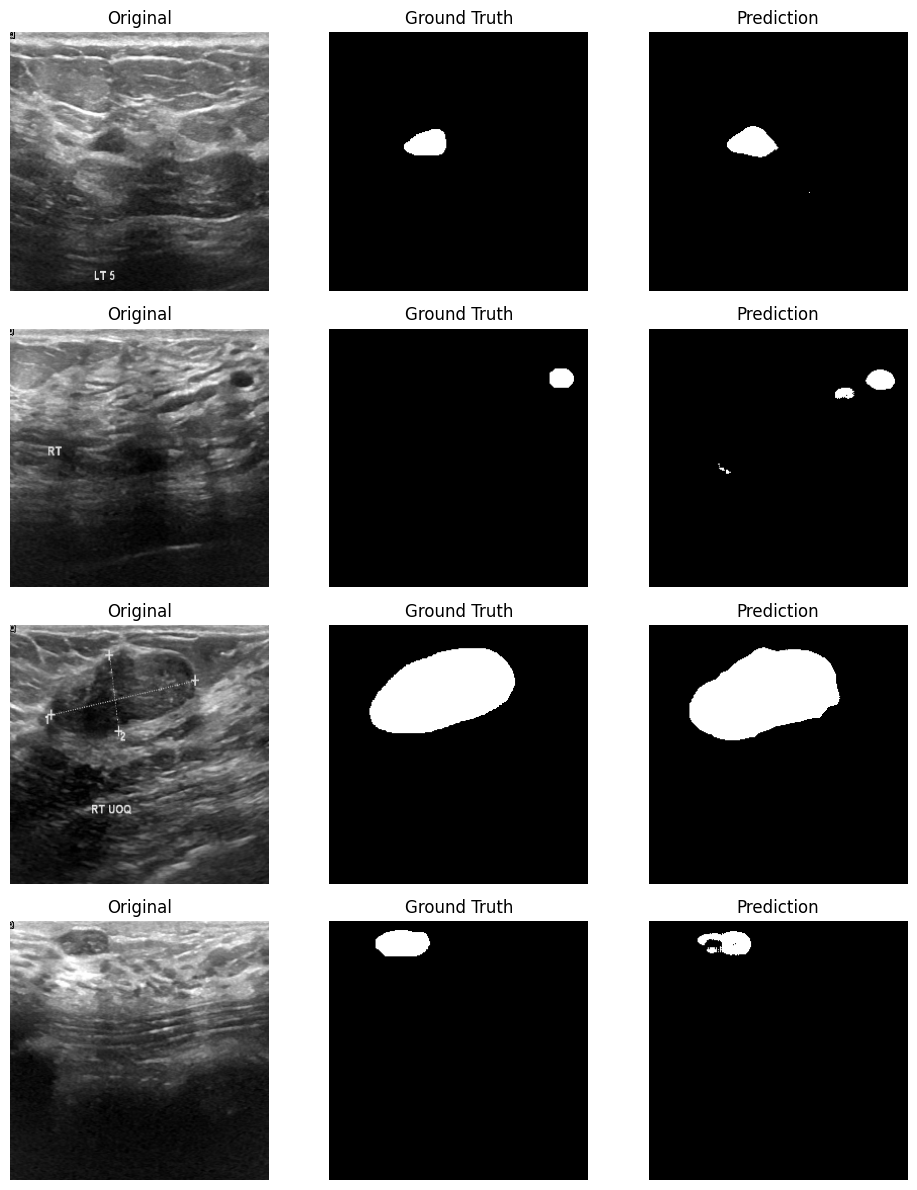

In [46]:
# ============================================================
# STEP 32: Visualize predictions
# ============================================================

fig, axes = plt.subplots(
    4,
    3,
    figsize=(10, 12)
)

for i in range(4):

    # Original image
    image = images_np[i]

    # Convert CHW -> HWC
    image = np.transpose(
        image,
        (1, 2, 0)
    )

    # Undo ImageNet normalization
    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image = image * std + mean

    image = np.clip(
        image,
        0,
        1
    )

    # Original
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(
        "Original"
    )
    axes[i, 0].axis("off")

    # Ground truth
    axes[i, 1].imshow(
        masks_np[i, 0],
        cmap="gray"
    )

    axes[i, 1].set_title(
        "Ground Truth"
    )

    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(
        preds_np[i, 0],
        cmap="gray"
    )

    axes[i, 2].set_title(
        "Prediction"
    )

    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

In [47]:
checkpoint = torch.load(
    "/content/best_attention_unet.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["val_dice"])

Best epoch: 19
Best validation Dice: 0.7813824765461007
